In [ ]:
!nvidia-smi

Tue Jan  6 18:24:10 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   69C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

!cp /content/gdrive/MyDrive/ColabNotebooks/train.zip /content

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
!unzip -q /content/train.zip -d /content/custom_data

In [ ]:
!ls /content/custom_data/train/images | wc -l

765


In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 59.1 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

!cp /content/gdrive/MyDrive/ColabNotebooks/valid.zip /content
!cp /content/gdrive/MyDrive/ColabNotebooks/test.zip /content

!unzip -q /content/valid.zip -d /content/custom_data
!unzip -q /content/test.zip -d /content/custom_data

!ls /content/custom_data/

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
^C
[/content/valid.zip]
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of /content/valid.zip or
        /content/valid.zip.zip, and cannot find /content/valid.zip.ZIP, period.
test  train


In [ ]:


!cp /content/gdrive/MyDrive/ColabNotebooks/valid.zip /content


!unzip -q /content/valid.zip -d /content/custom_data


!ls /content/custom_data/

test  train  valid


In [ ]:
import yaml
import os

def create_data_yaml(path_to_classes_txt, path_to_data_yaml):

  # Read classes.txt to get class names
  if not os.path.exists(path_to_classes_txt):
    print(f'classes.txt file not found! Please create a classes.txt labelmap and move it to {path_to_classes_txt}')
    return

  with open(path_to_classes_txt, 'r') as f:
    classes = []
    for line in f.readlines():
      if len(line.strip()) == 0: continue
      classes.append(line.strip())

  number_of_classes = len(classes)

  # Create data dictionary with train, val, and test
  data = {
      'path': '/content/custom_data',  # Base path
      'train': 'train/images',
      'val': 'valid/images',  # atau 'validation/images' sesuai nama folder
      'test': 'test/images',  # tambahkan test set
      'nc': number_of_classes,
      'names': classes
  }

  # Write data to YAML file
  with open(path_to_data_yaml, 'w') as f:
    yaml.dump(data, f, sort_keys=False)

  print(f'Created config file at {path_to_data_yaml}')

  # Verify folders exist
  print('\nVerifying folders:')
  base_path = data['path']
  for split in ['train', 'val', 'test']:
    folder_path = os.path.join(base_path, data[split])
    if os.path.exists(folder_path):
      num_images = len(os.listdir(folder_path))
      print(f'✓ {split}: {num_images} images found')
    else:
      print(f'✗ {split}: folder not found at {folder_path}')

  return

# Run function
path_to_classes_txt = '/content/custom_data/train/classes.txt'
path_to_data_yaml = '/content/data.yaml'

create_data_yaml(path_to_classes_txt, path_to_data_yaml)

print('\nFile contents:')
!cat /content/data.yaml

Created config file at /content/data.yaml

Verifying folders:
✓ train: 765 images found
✓ val: 206 images found
✓ test: 208 images found

File contents:
path: /content/custom_data
train: train/images
val: valid/images
test: test/images
nc: 21
names:
- Biogesic Paracetamol
- Decolgen
- Intunal F
- Intunal Kaplet
- Inza
- Mixagrip
- Mixagrip Flu dan Batuk
- Neozep Forte
- Oskadon SP
- Oskadon Sakit Kepala
- Pamol Paracetamol
- Panadol Cold Flu
- Panadol Extra Paracetamol
- Panadol Paracetamol
- Paramex
- Paramex Flu dan Batuk
- Paramex Nyeri Otot
- Poldan Mig
- Sanaflu
- Ultraflu
- Ultraflu Extra


In [ ]:
!yolo detect train data=/content/data.yaml model=yolo11s.pt epochs=100 imgsz=688 patience=30

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.248 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=688, int8=False, iou=0.7, keras=False, kob

=== Training Results ===


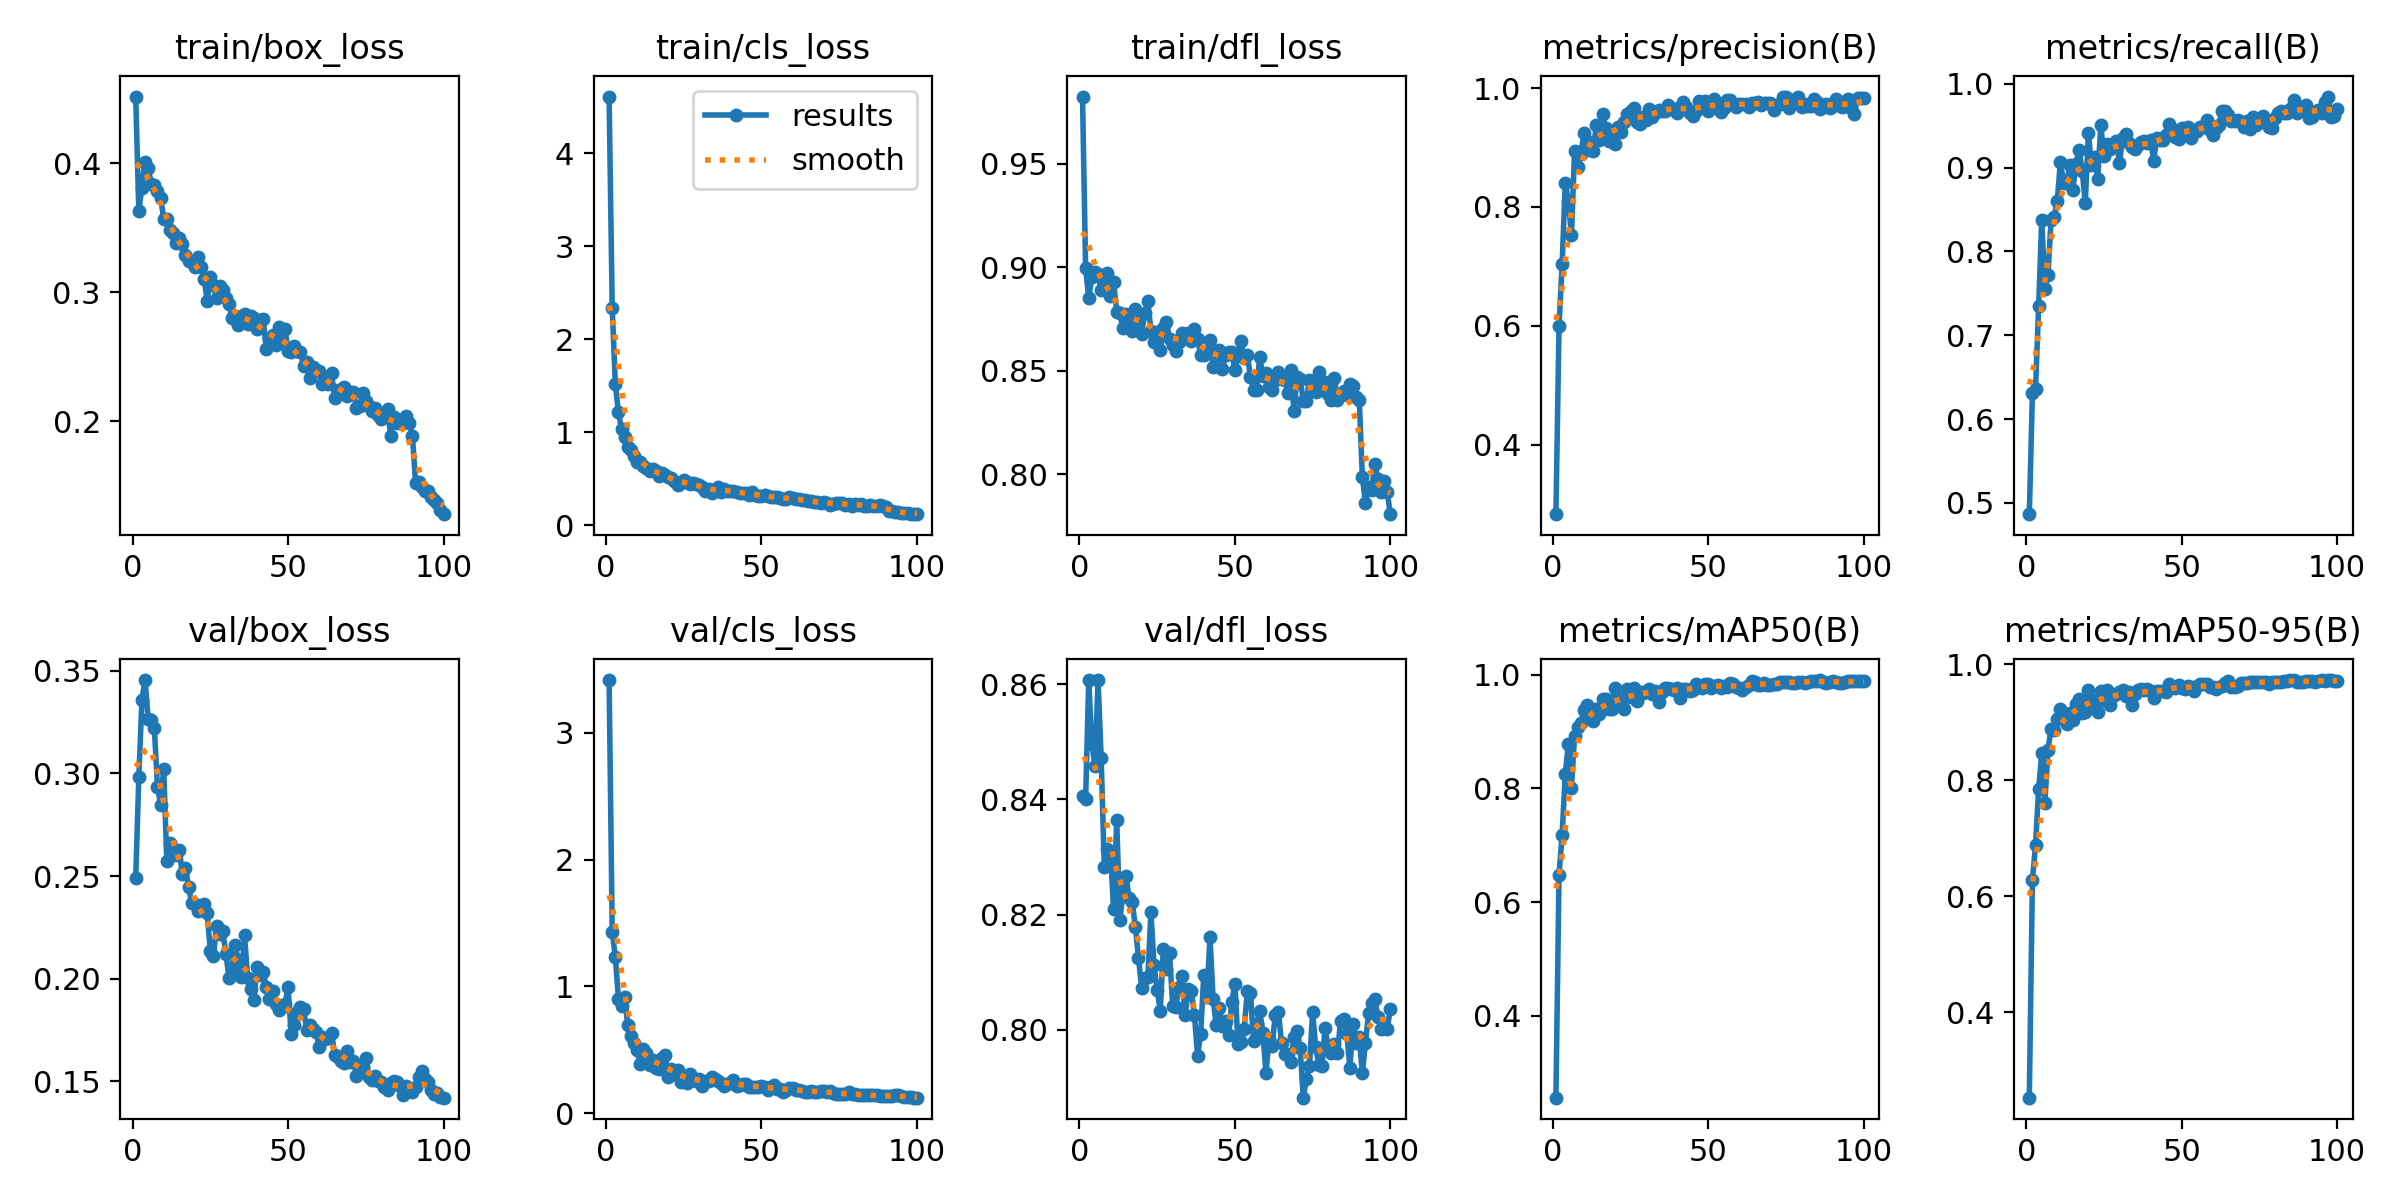


=== Confusion Matrix ===


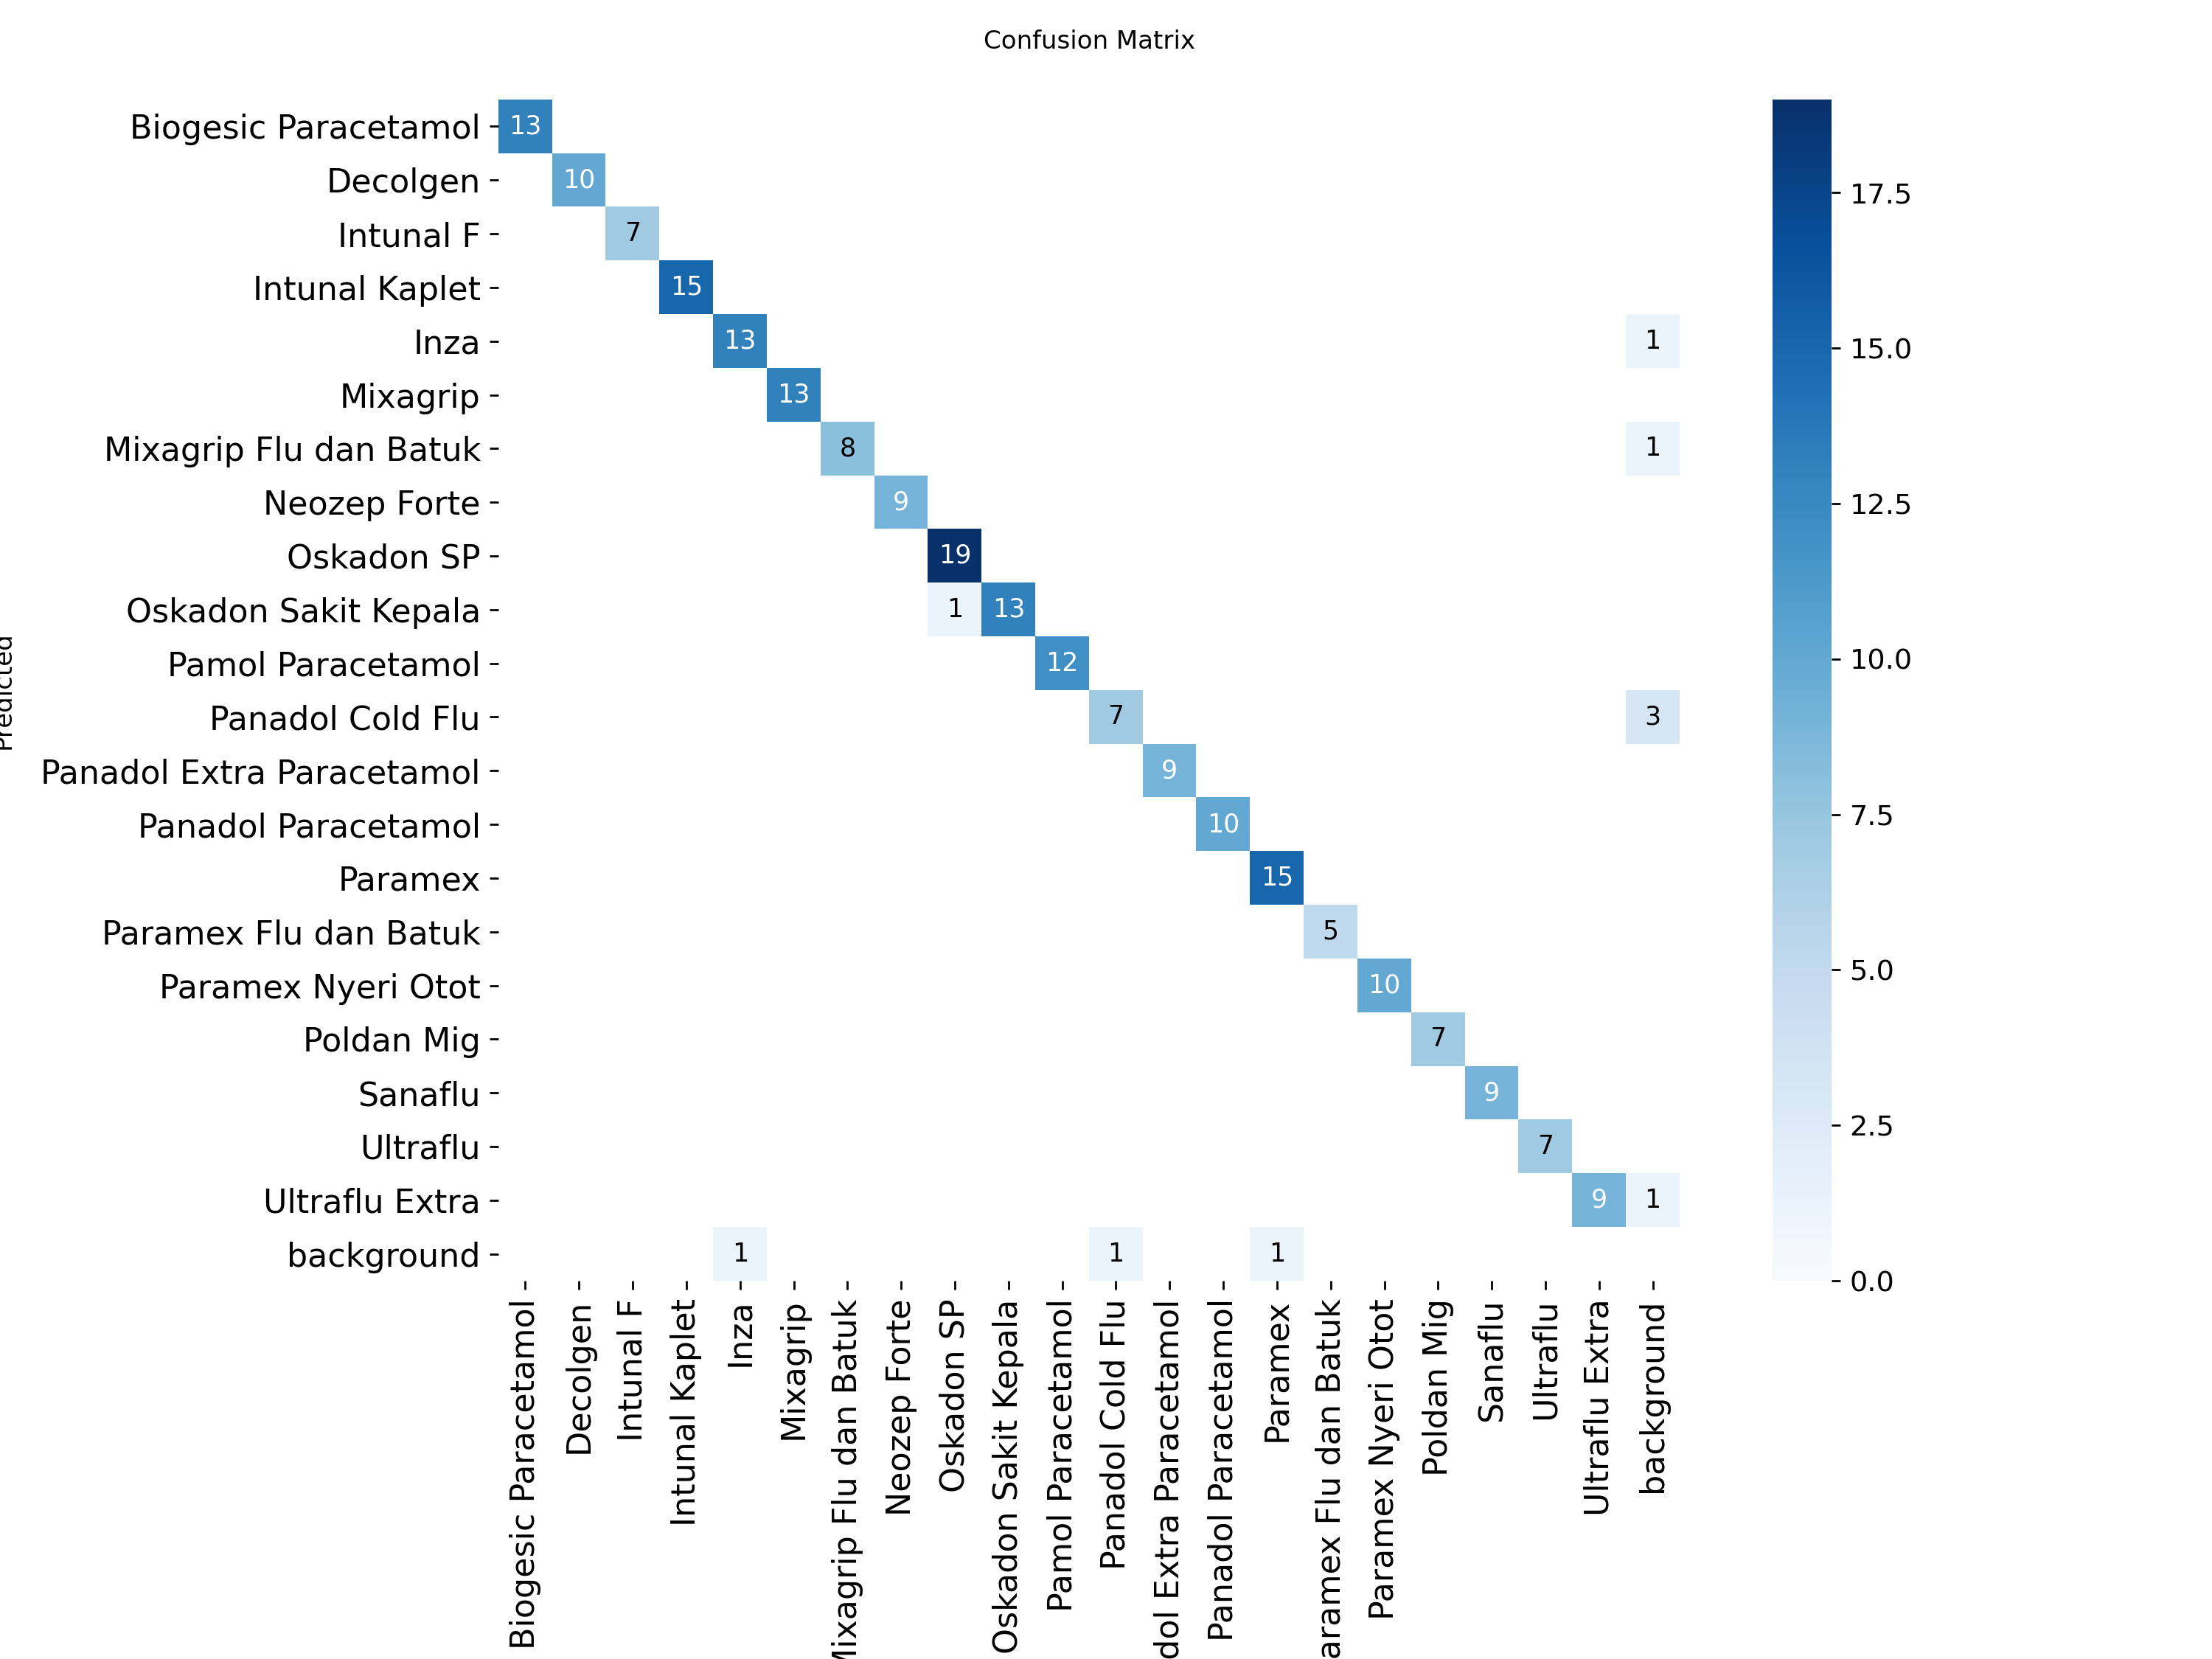


=== Validation Predictions ===


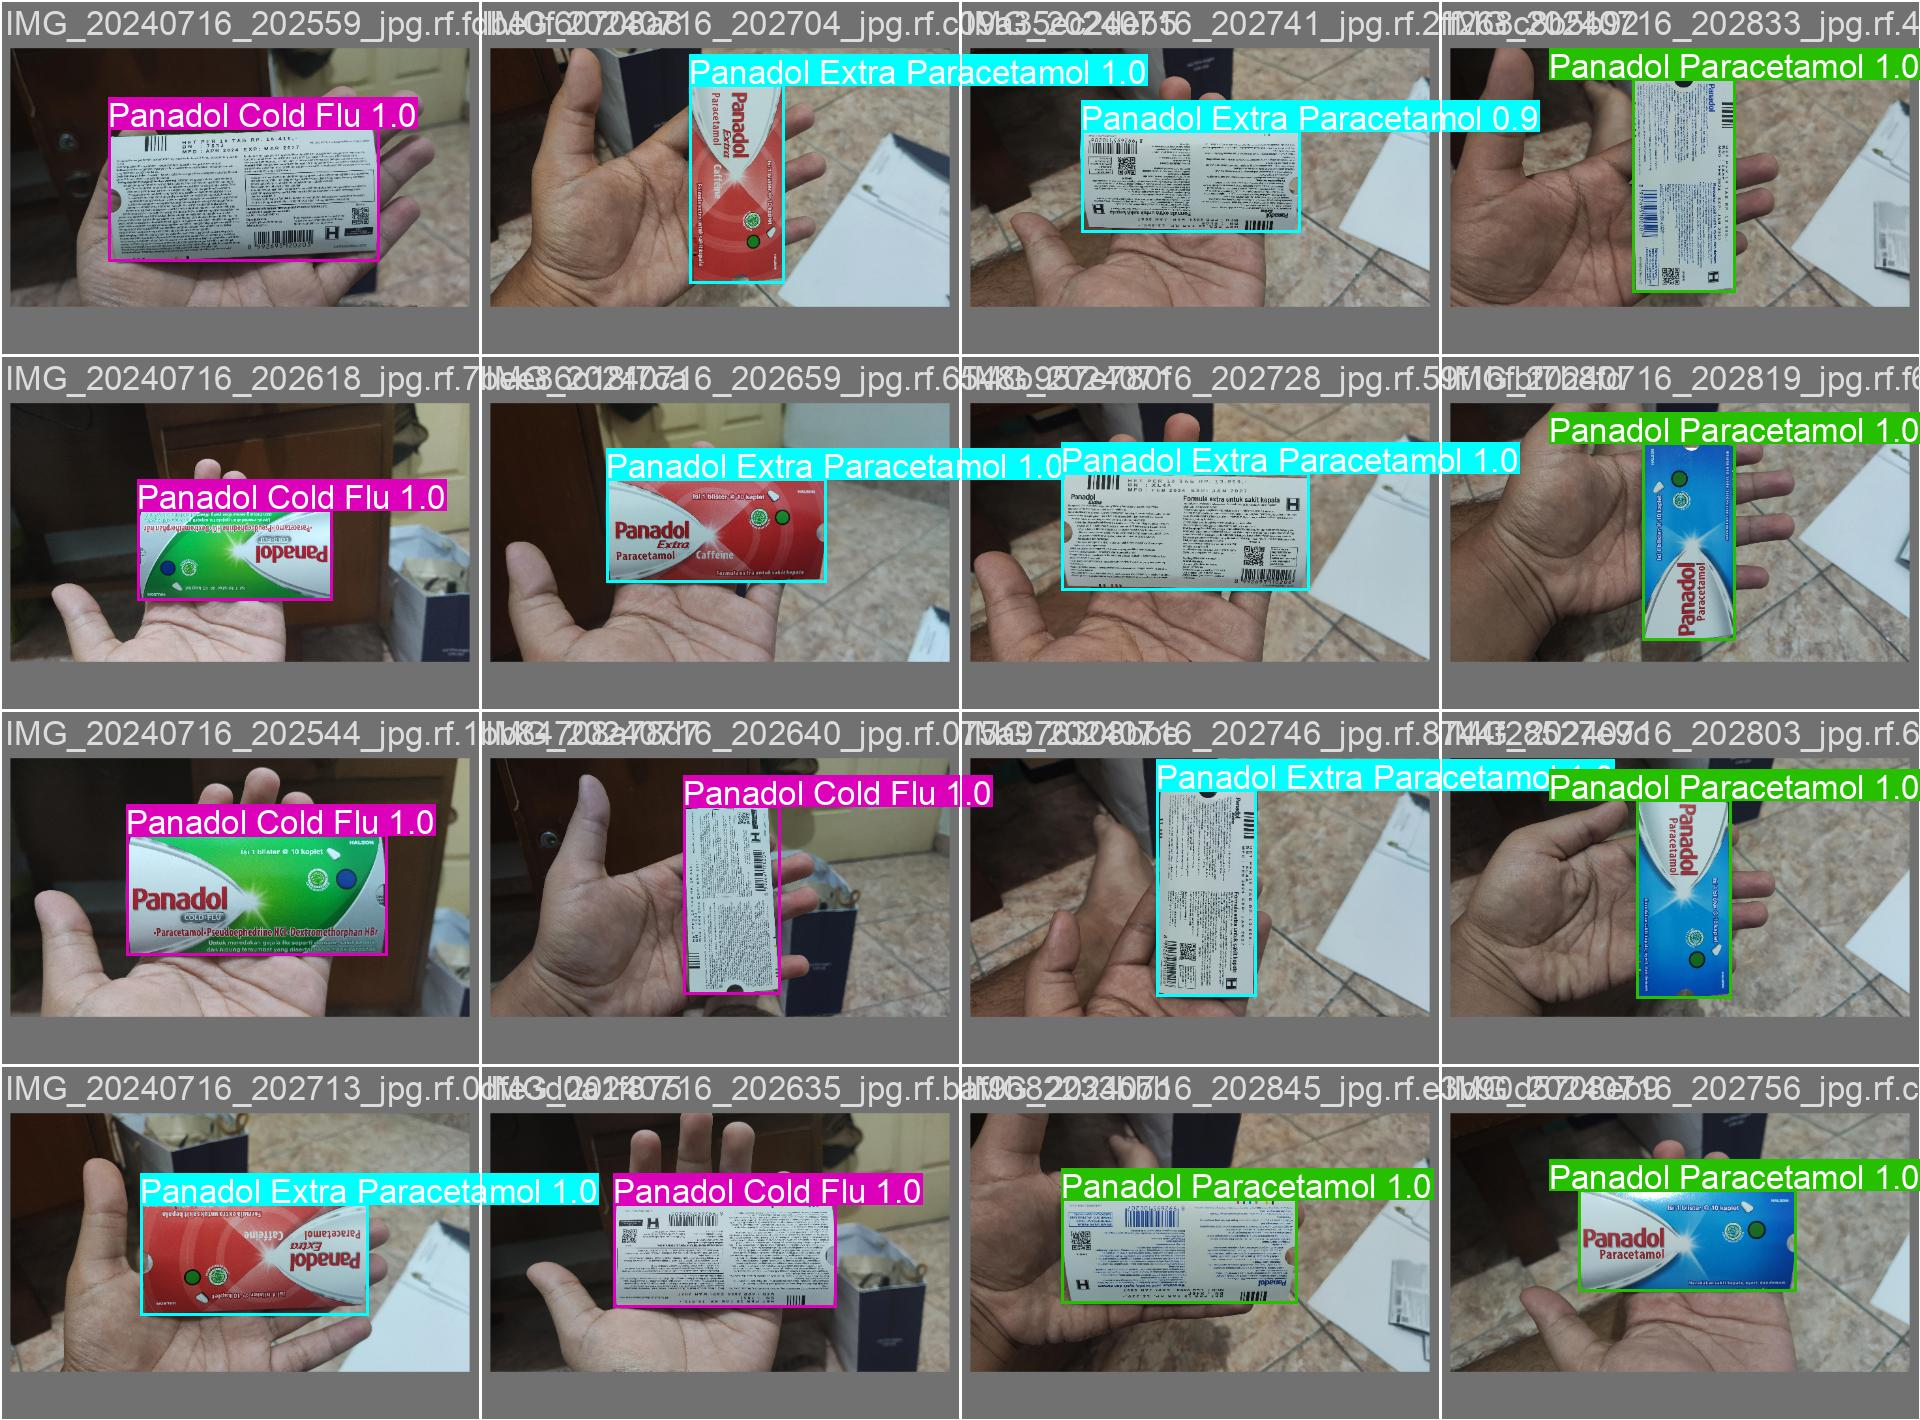

In [ ]:
# Tampilkan grafik training
from IPython.display import Image, display

print("=== Training Results ===")
display(Image(filename='runs/detect/train/results.png'))

print("\n=== Confusion Matrix ===")
display(Image(filename='runs/detect/train/confusion_matrix.png'))

print("\n=== Validation Predictions ===")
display(Image(filename='runs/detect/train/val_batch0_pred.jpg'))

In [ ]:
# Test performa model terbaik
!yolo detect val model=runs/detect/train/weights/best.pt data=/content/data.yaml

Ultralytics 8.3.248 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11s summary (fused): 100 layers, 9,420,927 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2781.8±167.9 MB/s, size: 1570.7 KB)
val: Scanning /content/custom_data/valid/labels.cache... 206 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 206/206 2.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 1.2s/it 16.1s
                   all        206        224      0.984      0.961      0.988      0.973
  Biogesic Paracetamol         13         13          1          1      0.995      0.995
              Decolgen         10         10      0.992          1      0.995      0.995
             Intunal F          7          7      0.989          1      0.995      0.995
        Intunal Kaplet         15         15      0.994          1      0.995      0.995
                  Inza         14      

In [ ]:
# Evaluasi final di test set
!yolo detect val model=runs/detect/train/weights/best.pt data=/content/data.yaml split=test

Ultralytics 8.3.248 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11s summary (fused): 100 layers, 9,420,927 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 106.4±19.4 MB/s, size: 817.3 KB)
val: Scanning /content/custom_data/test/labels... 208 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 208/208 365.3it/s 0.6s
val: New cache created: /content/custom_data/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 1.5s/it 19.9s
                   all        208        222      0.943      0.941      0.962      0.923
  Biogesic Paracetamol         11         11      0.957          1      0.995      0.988
              Decolgen          9          9      0.948          1      0.995      0.995
             Intunal F         11         11      0.957          1      0.995      0.995
        Intunal Kaplet         15         15      0.968          1      0.

In [ ]:
# === STEP 5: Download Model ===
!cp runs/detect/train/weights/best.pt /content/gdrive/MyDrive/yolo11s_medicine_best.pt
print("✅ Model saved!")

✅ Model saved!


In [23]:
!zip -r yolo_training_complete.zip runs/detect/train/
from google.colab import files
files.download('yolo_training_complete.zip')

  adding: runs/detect/train/ (stored 0%)
  adding: runs/detect/train/val_batch0_pred.jpg (deflated 10%)
  adding: runs/detect/train/train_batch2.jpg (deflated 4%)
  adding: runs/detect/train/train_batch4320.jpg (deflated 15%)
  adding: runs/detect/train/BoxPR_curve.png (deflated 27%)
  adding: runs/detect/train/val_batch1_labels.jpg (deflated 11%)
  adding: runs/detect/train/args.yaml (deflated 53%)
  adding: runs/detect/train/results.csv (deflated 63%)
  adding: runs/detect/train/BoxR_curve.png (deflated 19%)
  adding: runs/detect/train/val_batch2_labels.jpg (deflated 5%)
  adding: runs/detect/train/results.png (deflated 8%)
  adding: runs/detect/train/confusion_matrix.png (deflated 17%)
  adding: runs/detect/train/train_batch1.jpg (deflated 5%)
  adding: runs/detect/train/weights/ (stored 0%)
  adding: runs/detect/train/weights/last.pt (deflated 8%)
  adding: runs/detect/train/weights/best.pt (deflated 8%)
  adding: runs/detect/train/BoxF1_curve.png (deflated 15%)
  adding: runs/dete

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>